# สำรวจ G1 เดิน (Velocity Tracking) — ทำความเข้าใจ MDP

notebook นี้พา**เปิดฝากล่อง**ดูว่า task `Mjlab-Velocity-Flat-Unitree-G1`
ทำงานอย่างไร โดย**ไม่ต้องเทรนและไม่ต้องใช้ GPU** — รันบน Mac ได้เลย

**แนวคิดหลัก:** ใน RL หุ่นยนต์ทุกอย่างถูกจัดเป็น **MDP** (Markov Decision
Process) ซึ่งมี 4 ส่วน:

| ส่วน | คืออะไร | ใน G1 velocity |
|------|---------|----------------|
| **Observation** | สิ่งที่ policy 'เห็น' | มุมข้อต่อ, ความเร็ว, คำสั่ง twist, ... |
| **Action** | สิ่งที่ policy 'สั่ง' | target มุมข้อต่อ 29 ตัว |
| **Reward** | คะแนนบอกว่าทำดีไหม | เดินตามคำสั่ง + ทรงตัว - พลังงาน ... |
| **Termination** | เมื่อไหร่จบ episode | ล้ม / หมดเวลา |

mjlab สร้าง MDP นี้ด้วยระบบ **manager** ที่แยกแต่ละส่วนออกจากกัน เราจะ
ค่อยๆ แกะดูทีละส่วน

## 1) เตรียมสภาพแวดล้อม

import ที่จำเป็นและเลือก device อัตโนมัติ (ใช้ `cuda` ถ้ามี ไม่งั้น `cpu`)

> เราตั้ง `wp.config.quiet` เพื่อปิด log ของ MuJoCo Warp ตอน compile kernel
> ให้ output สะอาด (ครั้งแรกจะช้าหน่อยเพราะ compile — เป็นเรื่องปกติ)

In [1]:
import warp as wp

wp.config.quiet = True  # ปิด log 'Module ... load on device' ที่รกๆ

import torch

# mjlab ค้นหา task อัตโนมัติเมื่อ import mjlab.tasks
import mjlab.tasks  # noqa: F401  (ลงทะเบียน task ทั้งหมด)
from mjlab.envs import ManagerBasedRlEnv
from mjlab.tasks.registry import load_env_cfg

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

Warp DeprecationWarning: warp.config.quiet is deprecated; use warp.config.log_level = warp.LOG_WARNING to suppress the init banner.


device = cpu


## 2) โหลด config ของ task แล้วสร้าง environment

**แนวคิด:** `env_cfg` คือ 'พิมพ์เขียว' ของ MDP ทั้งอัน — บอกว่ามีหุ่นอะไร,
observation/reward/action เป็นแบบไหน. เราโหลดแบบ `play=True` เพื่อปิด
การรบกวน (noise) และ curriculum จะได้ดูพฤติกรรมสะอาดๆ

เราตั้ง `num_envs=16` (จำลอง 16 ตัวขนานกัน — GPU sim ทำได้เป็นพัน แต่ 16
พอสำหรับสำรวจบน CPU)

In [2]:
env_cfg = load_env_cfg("Mjlab-Velocity-Flat-Unitree-G1", play=True)
env_cfg.scene.num_envs = 16

env = ManagerBasedRlEnv(cfg=env_cfg, device=device)
print("สร้าง env สำเร็จ — จำนวน env ขนาน:", env.num_envs)

Warp 1.14.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/whoami/Library/Caches/warp/1.14.0


Module mujoco_warp._src.render_util d9a3176 load on device 'cpu' took 11.40 ms  (cached)
Module mujoco_warp._src.bvh fb7c74a load on device 'cpu' took 1.04 ms  (cached)

+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 16    |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.005 |
| Environment step-size  | 0.02  |
+------------------------+-------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | randomize_terrain          |
+--------+----------------------------+
+------------------------------------

Module mujoco_warp._src.io 056e107 load on device 'cpu' took 1.86 ms  (cached)
Module mujoco_warp._src.smooth 60df080 load on device 'cpu' took 2.09 ms  (cached)
Module _tile_cholesky_factorize_block__locals__kernel_1a8ac315 5261847 load on device 'cpu' took 0.77 ms  (cached)
Module _tile_cholesky_solve_block__locals__kernel_be7133b6 adae0a1 load on device 'cpu' took 0.74 ms  (cached)
สร้าง env สำเร็จ — จำนวน env ขนาน: 16


## 3) แกะดู Observation — 'สายตา' ของ policy

**แนวคิด:** policy ตัดสินใจจาก observation เท่านั้น มันไม่ได้เห็นโลกทั้งใบ
เห็นแค่ตัวเลขชุดหนึ่งที่เราเลือกป้อนให้. mjlab แบ่ง observation เป็น 'group'
เช่น `actor` (สิ่งที่ policy ใช้จริง) และ `critic` (ข้อมูลเพิ่มตอนเทรน)

เรา reset แล้วดูว่าแต่ละ group มีมิติเท่าไร และประกอบด้วย 'term' อะไรบ้าง

In [3]:
obs, info = env.reset()
print("observation groups:", list(obs.keys()))
for name, tensor in obs.items():
  print(f"  {name:8s}: shape = {tuple(tensor.shape)}")

Module reset_data__locals__reset_xfrc_applied_03030511 6442adb load on device 'cpu' took 1.16 ms  (cached)
Module reset_data__locals__reset_M_631075dd 270a798 load on device 'cpu' took 0.88 ms  (cached)
Module reset_data__locals__reset_mocap_6513201c ee8f7ba load on device 'cpu' took 0.88 ms  (cached)
Module reset_data__locals__reset_contact_5c08f689 9d2cde1 load on device 'cpu' took 0.57 ms  (cached)
Module reset_data__locals__reset_sleep_50b990da 5427725 load on device 'cpu' took 0.89 ms  (cached)
Module reset_data__locals__reset_nworld_69a10925 c22681c load on device 'cpu' took 0.76 ms  (cached)
Module _nxn_broadphase__locals__kernel_df6640ed 8a5d6ba load on device 'cpu' took 0.90 ms  (cached)


Module _primitive_narrowphase__locals__primitive_narrowphase_0d45ffc8 44465d3 load on device 'cpu' took 1.12 ms  (cached)
Module mujoco_warp._src.constraint 1055a87 load on device 'cpu' took 0.61 ms  (cached)
Module _friction_dof__locals__kernel_196c77d2 ed54ad1 load on device 'cpu' took 1.46 ms  (cached)


Module _limit_slide_hinge__locals__kernel_6e38514e f43752c load on device 'cpu' took 1.99 ms  (cached)
Module _efc_contact_init__locals__kernel_6eab31b8 98d11aa load on device 'cpu' took 0.84 ms  (cached)
Module _efc_contact_jac_sparse__locals__kernel_f9099d1d 97893ca load on device 'cpu' took 0.56 ms  (cached)
Module _efc_contact_update__locals__kernel_8aad7bfd 2b56b7e load on device 'cpu' took 0.56 ms  (cached)
Module mujoco_warp._src.sensor 5b546e1 load on device 'cpu' took 1.54 ms  (cached)
Module mujoco_warp._src.forward 70f2f91 load on device 'cpu' took 1.07 ms  (cached)
Module mujoco_warp._src.passive 9ef5a40 load on device 'cpu' took 1.23 ms  (cached)
Module _qfrc_smooth__locals__kernel_6eb3d958 21660d5 load on device 'cpu' took 0.77 ms  (cached)


Module mujoco_warp._src.support db2c7c5 load on device 'cpu' took 0.90 ms  (cached)
Module _tile_cholesky_factorize_solve_block__locals__kernel_beb64870 9cce3cd load on device 'cpu' took 0.94 ms  (cached)
Module _solve_init_dof__locals__kernel_c6f567bf 9a52ad9 load on device 'cpu' took 0.62 ms  (cached)
Module mujoco_warp._src.solver e3858a2 load on device 'cpu' took 1.44 ms  (cached)
Module _solve_init_jaref_kernel__locals__kernel_1971c1c1 ed9adac load on device 'cpu' took 0.80 ms  (cached)
Module mul_m_kernel__locals___mul_m_fd2186c4 026f940 load on device 'cpu' took 1.43 ms  (cached)
Module _update_constraint_efc__locals__kernel_4af8f110 fc7fac2 load on device 'cpu' took 0.98 ms  (cached)
Module _update_constraint_init_qfrc_constraint_sparse__locals__kernel_16efb537 0d9a44e load on device 'cpu' took 1.32 ms  (cached)
Module _update_gradient_zero_grad_dot__locals__kernel_cb780630 407be49 load on device 'cpu' took 0.72 ms  (cached)
Module _update_gradient_grad__locals__kernel_0cbf4927

Module _linesearch_iterative_kernel__locals__kernel_59bb1059 ad60e77 load on device 'cpu' took 1.09 ms  (cached)
Module _update_constraint_efc__locals__kernel_e30beb1f add8868 load on device 'cpu' took 1.03 ms  (cached)
Module _update_gradient_zero_grad_dot__locals__kernel_f708ee5f f6af282 load on device 'cpu' took 0.56 ms  (cached)
Module _update_gradient_grad__locals__kernel_cb93df65 99de580 load on device 'cpu' took 0.57 ms  (cached)
Module _update_gradient_h_incremental_sparse__locals__kernel_abf1f59a a136f23 load on device 'cpu' took 0.54 ms  (cached)
Module _update_gradient_cholesky_blocked_skip_unchanged__locals__kernel_955af8fc 60323d9 load on device 'cpu' took 1.18 ms  (cached)
Module _contact_sort__locals__contact_sort_321f5f3e 5a98d63 load on device 'cpu' took 0.44 ms  (cached)


Module mujoco_warp._src.ray 3e72851 load on device 'cpu' took 1.54 ms  (cached)
observation groups: ['actor', 'critic']
  actor   : shape = (16, 99)
  critic  : shape = (16, 111)


In [4]:
# แจกแจงว่า group 'policy' ประกอบด้วย term อะไรบ้าง (แต่ละ term คือ obs ย่อย)
obs_mgr = env.observation_manager
for group in obs_mgr.active_terms:
  print(f"group {group!r}:")
  for term_name in obs_mgr.active_terms[group]:
    print("   -", term_name)

group 'actor':
   - base_lin_vel
   - base_ang_vel
   - projected_gravity
   - joint_pos
   - joint_vel
   - actions
   - command
group 'critic':
   - base_lin_vel
   - base_ang_vel
   - projected_gravity
   - joint_pos
   - joint_vel
   - actions
   - command
   - foot_height
   - foot_air_time
   - foot_contact
   - foot_contact_forces


**สังเกต:** obs term เช่น `velocity_commands` คือคำสั่ง twist ที่เราอยากให้
หุ่นเดินตาม, `joint_pos`/`joint_vel` คือสถานะข้อต่อ, `actions` คือ action
ก่อนหน้า (ให้ policy รู้ว่าเพิ่งสั่งอะไรไป). ทั้งหมดถูกต่อกันเป็นเวกเตอร์เดียว
ป้อนเข้า neural network

## 4) แกะดู Action — 'มือ' ของ policy

**แนวคิด:** ทุก step policy ส่ง action ออกมา ในงานนี้ action คือ **target
มุมของข้อต่อ 29 ตัว** (position control). ActionManager จะแปลง action → คำสั่ง
ที่ actuator เข้าใจ (มี scale + offset จากท่ายืน)

In [5]:
act_mgr = env.action_manager
print("มิติ action รวม:", act_mgr.total_action_dim)
print("action terms:", list(act_mgr.active_terms))
print()
print("ตัวอย่างชื่อข้อต่อ 10 ตัวแรกที่ควบคุม:")
robot = env.scene["robot"]
for name in robot.joint_names[:10]:
  print("  -", name)

มิติ action รวม: 29
action terms: ['joint_pos']

ตัวอย่างชื่อข้อต่อ 10 ตัวแรกที่ควบคุม:
  - left_hip_pitch_joint
  - left_hip_roll_joint
  - left_hip_yaw_joint
  - left_knee_joint
  - left_ankle_pitch_joint
  - left_ankle_roll_joint
  - right_hip_pitch_joint
  - right_hip_roll_joint
  - right_hip_yaw_joint
  - right_knee_joint


## 5) ขับ env ด้วย action ทดสอบ แล้วดูว่าเกิดอะไรขึ้น

**แนวคิด:** เพื่อเข้าใจ loop ของ RL เราลองส่ง action เอง(ยังไม่มี policy)
แล้วดู reward กับ termination. เราลอง 2 แบบ:
- **zero action** = สั่ง target = ท่า default (หุ่นพยายามยืนนิ่ง)
- **random action** = สั่งมั่ว (หุ่นจะโซเซ)

นี่คือสิ่งที่คำสั่ง `uv run play ... --agent zero/random` ทำเบื้องหลัง

In [6]:
def rollout(action_fn, steps=50):
  """รัน env ตาม action_fn ที่กำหนด แล้วคืนค่า reward เฉลี่ยต่อ step."""
  obs, _ = env.reset()
  total = torch.zeros(env.num_envs, device=device)
  n_done = 0
  for _ in range(steps):
    action = action_fn()
    obs, reward, terminated, truncated, info = env.step(action)
    total += reward
    n_done += int((terminated | truncated).sum().item())
  return (total / steps).mean().item(), n_done


dim = act_mgr.total_action_dim
zero_r, zero_done = rollout(lambda: torch.zeros(env.num_envs, dim, device=device))
rand_r, rand_done = rollout(lambda: torch.randn(env.num_envs, dim, device=device) * 0.5)
print(f"zero action   : reward/step = {zero_r:+.3f}, จำนวนครั้งที่จบ episode = {zero_done}")
print(f"random action : reward/step = {rand_r:+.3f}, จำนวนครั้งที่จบ episode = {rand_done}")

Module mujoco_warp._src.derivative 761668c load on device 'cpu' took 1.72 ms  (cached)
Module _next_time_builder__locals___next_time_95ad6d7a e26b00c load on device 'cpu' took 0.99 ms  (cached)


zero action   : reward/step = +0.059, จำนวนครั้งที่จบ episode = 0
random action : reward/step = -0.004, จำนวนครั้งที่จบ episode = 0


**สิ่งที่คาดหวัง:** zero action ควรได้ reward สูงกว่า random เพราะการยืนนิ่ง
เข้าใกล้พฤติกรรมที่ reward ออกแบบไว้มากกว่าการสั่งมั่ว (ซึ่งทำให้ล้ม → จบ
episode บ่อย). ตัวเลขนี้แสดงว่า reward function 'ชี้ทาง' ให้ policy อย่างไร

## 6) แกะ Reward ทีละก้อน — หัวใจของการออกแบบ task

**แนวคิด:** reward รวมคือผลบวกถ่วงน้ำหนักของ 'term' ย่อยหลายอัน เช่น
รางวัลเดินตามคำสั่ง (+), โทษการใช้พลังงาน (−), โทษท่าเอียง (−). การดูแยกทีละ
term ทำให้เข้าใจว่า task ให้ความสำคัญกับอะไร

In [7]:
# ดึงชื่อ reward term ที่ active จาก manager
print("reward terms ที่ทำงานอยู่:")
for name in env.reward_manager.active_terms:
  print("  -", name)

reward terms ที่ทำงานอยู่:
  - track_linear_velocity
  - track_angular_velocity
  - upright
  - pose
  - body_ang_vel
  - angular_momentum
  - dof_pos_limits
  - action_rate_l2
  - air_time
  - foot_clearance
  - foot_swing_height
  - foot_slip
  - soft_landing
  - self_collisions


In [8]:
# ดูน้ำหนักของแต่ละ term จาก cfg โดยตรง (บวก=อยากให้เกิด, ลบ=อยากเลี่ยง)
for name, term_cfg in env_cfg.rewards.items():
  print(f"  {name:28s} weight = {term_cfg.weight:+.4f}")

  track_linear_velocity        weight = +2.0000
  track_angular_velocity       weight = +2.0000
  upright                      weight = +1.0000
  pose                         weight = +1.0000
  body_ang_vel                 weight = -0.0500
  angular_momentum             weight = -0.0200
  dof_pos_limits               weight = -1.0000
  action_rate_l2               weight = -0.1000
  air_time                     weight = +0.0000
  foot_clearance               weight = -2.0000
  foot_swing_height            weight = -0.2500
  foot_slip                    weight = -0.1000
  soft_landing                 weight = -0.0000
  self_collisions              weight = -1.0000


**อ่านผล:** term ที่ weight เป็นบวกคือสิ่งที่เรา 'อยากให้เกิด' (เช่น
`track_lin_vel` = เดินตามความเร็วที่สั่ง), ส่วน weight ลบคือสิ่งที่ 'อยากเลี่ยง'
(เช่น `action_rate` = เปลี่ยน action กระตุก, `dof_acc` = ข้อต่อเร่งแรงเกิน).
การจูนน้ำหนักเหล่านี้คือ 90% ของงานออกแบบ task RL

## 7) เรนเดอร์ภาพ — เห็นหุ่นด้วยตา

**แนวคิด:** env เก็บสถานะทางฟิสิกส์เป็นตัวเลข เราใช้ `mujoco.Renderer`
แปลงเป็นภาพ. ตรงนี้เรา reset แล้วเรนเดอร์ท่าเริ่มต้นของ G1 หนึ่งตัว

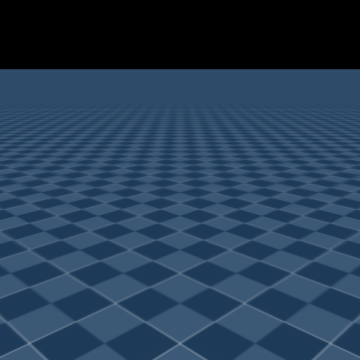

In [9]:
import mujoco
from PIL import Image

obs, _ = env.reset()

# ดึง MuJoCo model/data ตัวแรกออกมาเรนเดอร์
m = env.sim.mj_model
d = mujoco.MjData(m)
qpos0 = env.sim.data.qpos[0].detach().cpu().numpy()
d.qpos[: len(qpos0)] = qpos0
mujoco.mj_forward(m, d)

renderer = mujoco.Renderer(m, height=360, width=360)
cam = mujoco.MjvCamera()
cam.lookat[:] = [0, 0, 0.7]
cam.distance = 2.2
cam.azimuth = 135
cam.elevation = -15
renderer.update_scene(d, cam)
Image.fromarray(renderer.render())

## 8) สรุป — คุณเพิ่งเข้าใจอะไรไปบ้าง

- **MDP** ของ G1 velocity = observation (สถานะ+คำสั่ง) → action (target
  ข้อต่อ) → reward (เดินตามคำสั่ง+ทรงตัว) → termination (ล้ม/หมดเวลา)
- mjlab ประกอบ MDP ด้วย **manager** ที่แยกส่วน ทำให้ปรับแต่งทีละส่วนได้
- **ยังไม่มี policy** — เราขับด้วย zero/random เพื่อดูว่า reward ชี้ทางอย่างไร
  ขั้นถัดไปคือให้ PPO เรียนรู้ policy ที่ทำ reward สูงสุด (ต้องใช้ GPU)

**ลองต่อเอง:** เปลี่ยน `env_cfg.commands['twist'].ranges.lin_vel_x` แล้วดูว่า
คำสั่งความเร็วใน observation เปลี่ยนไหม, หรือเพิ่ม `steps` ใน rollout

ดู notebook คู่กัน `explore_g1_manipulation.ipynb` สำหรับ G1 + มือหยิบของ